In [ ]:

# STEP 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# TensorFlow / Keras tools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [ ]:

# STEP 2: UPLOAD THE CSV FILE

from google.colab import files

uploaded = files.upload()

# Show the name of the uploaded file
for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving final_reviews.csv to final_reviews.csv
Uploaded file: final_reviews.csv


In [ ]:
# STEP 3: LOAD THE DATASET

# Get the file name automatically from the upload step
file_name = list(uploaded.keys())[0]

# Read the CSV into a DataFrame
df = pd.read_csv(file_name)

print("File loaded:", file_name)

# Shape: (number of rows, number of columns)
print("\nDataset shape:", df.shape)

# Column names
print("\nColumns:")
print(list(df.columns))

# First 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Random sample rows (gives a better feel for the data)
print("\nRandom 5 rows:")
display(df.sample(5, random_state=42))

File loaded: final_reviews.csv

Dataset shape: (2400, 2)

Columns:
['text', 'label']

First 5 rows:


,text,label
0,"For work trips, this hotel delivers. Fast WiFi...",fake_ai
1,"Facilities cover business desk, pool, and lau...",fake_ai
2,we love the location and proximity to everythi...,genuine
3,"Wow, what a fantastic experience! Spotless cle...",fake_ai
4,Practical choice for work trips. WiFi delivere...,fake_ai



Random 5 rows:


,text,label
2037,Upon arrival at the Ambassador East Hotel in C...,fake_human
1978,"I booked this hotel on Priceline for 4/13, and...",genuine
855,"Amenities cover on-site dining, gym use, and ...",fake_ai
1719,This hotel was ideal for our family vacation!...,fake_ai
2019,My 3 nieces and I stayed here for a long weeke...,genuine


In [ ]:

# STEP 4: BASIC DATA CHECKS


# Data type and non-null count for each column
print("Dataset info:")
df.info()

# Missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Number of fully duplicated rows
print("\nDuplicate rows:", df.duplicated().sum())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2400 non-null   object
 1   label   2400 non-null   object
dtypes: object(2)
memory usage: 37.6+ KB

Missing values per column:
text     0
label    0
dtype: int64

Duplicate rows: 4


In [ ]:

# STEP 5 : FIND THE LABEL COLUMN

for col in df.columns:
    n_unique = df[col].nunique()
    # A label column normally has only a few different values
    if n_unique <= 10:
        print(f"Column '{col}' has {n_unique} unique values:")
        print(df[col].value_counts(dropna=False))
        print("-" * 40)

# Also show the average text length of each text-like column
print("\nAverage length (characters) of text columns:")
for col in df.select_dtypes(include="object").columns:
    print(col, "->", round(df[col].astype(str).str.len().mean(), 1))

Column 'label' has 3 unique values:
label
fake_ai       800
genuine       800
fake_human    800
Name: count, dtype: int64
----------------------------------------

Average length (characters) of text columns:
text -> 601.7
label -> 8.0


In [ ]:

# STEP 6: CLEAN THE TABLE

# Give the columns simple names we will use for the rest of the project
TEXT_COL = "text"
LABEL_COL = "label"

# 1. Drop rows where the text or label is missing (none in your data, but safe to keep)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])

# 2. Remove duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows. Rows left: {len(df)}")

# 3. Convert the 3 original labels into 2 classes
#    genuine -> 0 (Genuine), fake_ai and fake_human -> 1 (Fake)
label_map = {"genuine": 0, "fake_ai": 1, "fake_human": 1}
df["target"] = df[LABEL_COL].map(label_map)

# Safety check: if any label was not in our map, it becomes NaN
print("Unmapped labels:", df["target"].isnull().sum())

# 4. Show the new class counts
print("\nClass counts (0 = Genuine, 1 = Fake):")
print(df["target"].value_counts())

Removed 4 duplicate rows. Rows left: 2396
Unmapped labels: 0

Class counts (0 = Genuine, 1 = Fake):
target
1    1600
0     796
Name: count, dtype: int64


In [ ]:

# STEP 7: CLEAN THE TEXT


def clean_text(text):
    """Lowercase the text and remove unnecessary punctuation."""
    text = str(text).lower()                    # 1. lowercase everything
    text = re.sub(r"http\S+|www\S+", " ", text) # 2. remove web links
    text = re.sub(r"[^a-z0-9\s]", " ", text)    # 3. keep only letters, numbers, spaces
    text = re.sub(r"\s+", " ", text).strip()    # 4. collapse extra spaces
    return text

# Apply the function to every review
df["clean_text"] = df[TEXT_COL].apply(clean_text)

# Compare original and cleaned text
print("BEFORE vs AFTER cleaning:\n")
for i in range(3):
    print("Original:", df[TEXT_COL][i][:150])
    print("Cleaned :", df["clean_text"][i][:150])
    print("-" * 60)

# Drop any review that became empty after cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print("Final dataset size:", df.shape)

BEFORE vs AFTER cleaning:

Original: For work trips, this hotel delivers. Fast WiFi for uninterrupted productivity. Workspace practical and comfortable. Efficiency in staff service notabl
Cleaned : for work trips this hotel delivers fast wifi for uninterrupted productivity workspace practical and comfortable efficiency in staff service notable de
------------------------------------------------------------
Original:  Facilities cover business desk, pool, and laundry service. Location convenient enough. Rooms functional. Staff professional. Overall satisfactory. 
Cleaned : facilities cover business desk pool and laundry service location convenient enough rooms functional staff professional overall satisfactory
------------------------------------------------------------
Original: we love the location and proximity to everything. The staff was very friendly and courteous. They were so nice to our 2.5 year old boy. got his backpa
Cleaned : we love the location and proximity to everything 

In [ ]:

# STEP 8: REMOVE DUPLICATES / CONFLICTS AFTER CLEANING

print("Rows before:", len(df))

# 1. Find cleaned texts that appear with BOTH labels (conflicting)
labels_per_text = df.groupby("clean_text")["target"].nunique()
conflicting_texts = labels_per_text[labels_per_text > 1].index
print("Texts with conflicting labels:", len(conflicting_texts))

# Remove them completely (we can't know which label is right)
df = df[~df["clean_text"].isin(conflicting_texts)]

# 2. Remove duplicate cleaned texts (keep the first one)
dups = df.duplicated(subset="clean_text").sum()
print("Duplicate cleaned texts:", dups)
df = df.drop_duplicates(subset="clean_text").reset_index(drop=True)

print("Rows after:", len(df))
print("\nClass counts (0 = Genuine, 1 = Fake):")
print(df["target"].value_counts())

Rows before: 2396
Texts with conflicting labels: 0
Duplicate cleaned texts: 0
Rows after: 2396

Class counts (0 = Genuine, 1 = Fake):
target
1    1600
0     796
Name: count, dtype: int64


In [ ]:
# STEP 9: TRAIN / TEST SPLIT

X = df["clean_text"]        # the input: cleaned review text
y = df["target"].values     # the answer: 0 = Genuine, 1 = Fake

# 80% for training, 20% for testing
# stratify=y keeps the Genuine/Fake ratio the same in both sets
# random_state=42 makes the split repeatable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews :", len(X_test))
print("\nFake ratio in train:", round(y_train.mean(), 3))
print("Fake ratio in test :", round(y_test.mean(), 3))

Training reviews: 1916
Testing reviews : 480

Fake ratio in train: 0.668
Fake ratio in test : 0.669


In [ ]:
# STEP 10: TF-IDF + CLASS WEIGHTS

from sklearn.utils.class_weight import compute_class_weight

# TF-IDF turns each review into a list of numbers.
# - max_features=5000 : keep only the 5000 most useful words/phrases
# - ngram_range=(1,2) : use single words AND two-word phrases ("very clean")
# - min_df=2          : ignore words that appear in fewer than 2 reviews (noise)
# - sublinear_tf=True : stops very repeated words from dominating
# We do NOT remove stop words, because words like "the" and "and" can
# reveal writing style, which helps separate AI/fake text from real text.
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# fit_transform on TRAINING data only: learns the vocabulary and converts it
X_train_tfidf = tfidf.fit_transform(X_train).toarray().astype("float32")

# transform on TEST data: uses the vocabulary learned from training only
X_test_tfidf = tfidf.transform(X_test).toarray().astype("float32")

print("Train feature shape:", X_train_tfidf.shape)
print("Test feature shape :", X_test_tfidf.shape)

# A few example features the model will use
print("\nSample features:", list(tfidf.get_feature_names_out()[:15]))

# Class weights: give the smaller class (Genuine) more importance
weights = compute_class_weight(class_weight="balanced",
                               classes=np.array([0, 1]), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print("\nClass weights:", class_weights)

Train feature shape: (1916, 5000)
Test feature shape : (480, 5000)

Sample features: ['00', '10', '10 minutes', '100', '11', '12', '13', '14', '15', '15 minutes', '20', '20 minutes', '200', '2007', '2009']

Class weights: {0: np.float64(1.5039246467817897), 1: np.float64(0.7490226739640344)}


In [ ]:
# STEP 11: BUILD AND COMPILE THE MODEL

# Fix random seeds so results are repeatable
tf.keras.utils.set_random_seed(42)

# Number of input features (should be 5000, or fewer if the vocabulary is smaller)
input_dim = X_train_tfidf.shape[1]

model = keras.Sequential([
    # Input layer: one number for each TF-IDF feature
    layers.Input(shape=(input_dim,)),

    # First hidden layer: 64 neurons with ReLU
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),                 # randomly turn off 50% of neurons while training

    # Second hidden layer: 32 neurons with ReLU
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),                 # turn off 30% of neurons while training

    # Output layer: 1 neuron with Sigmoid -> probability that the review is Fake
    layers.Dense(1, activation="sigmoid")
])

# Compile: choose the optimizer, the loss, and what to track
model.compile(
    optimizer="adam",                    # Adam optimizer
    loss="binary_crossentropy",          # loss for 2-class problems
    metrics=["accuracy"]
)

# Show the structure of the network
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,177 (1.23 MB)

 Trainable params: 322,177 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 12: TRAIN THE MODEL

# Set aside 20% of the TRAINING data as a validation set.
# The model does not learn from it; we use it to check progress after each epoch.
# The TEST set stays untouched until the final evaluation.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tfidf, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Early stopping: stop if validation loss doesn't improve for 5 epochs,
# then go back to the best weights seen during training
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Convert class weights to plain Python floats (safe for Keras)
class_weights_clean = {0: float(class_weights[0]), 1: float(class_weights[1])}

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,                           # maximum epochs (early stopping may end sooner)
    batch_size=32,                       # learn from 32 reviews at a time
    class_weight=class_weights_clean,    # handle the Genuine/Fake imbalance
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining finished after", len(history.history["loss"]), "epochs.")

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.5359 - loss: 0.6733 - val_accuracy: 0.7552 - val_loss: 0.6328
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8205 - loss: 0.5054 - val_accuracy: 0.8906 - val_loss: 0.3700
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9426 - loss: 0.2336 - val_accuracy: 0.9141 - val_loss: 0.2209
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9719 - loss: 0.1124 - val_accuracy: 0.9141 - val_loss: 0.1916
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9883 - loss: 0.0587 - val_accuracy: 0.8906 - val_loss: 0.2061
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9961 - loss: 0.0358 - val_accuracy: 0.8984 - val_loss: 0.2034
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9954 - loss: 0.0247 - val_accuracy: 0.9010 - val_loss: 0.2245
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0162 - val_accuracy: 0.9010 - val_lo

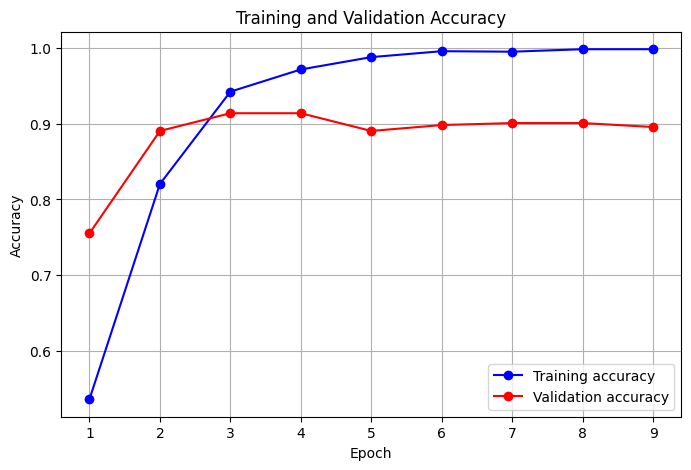

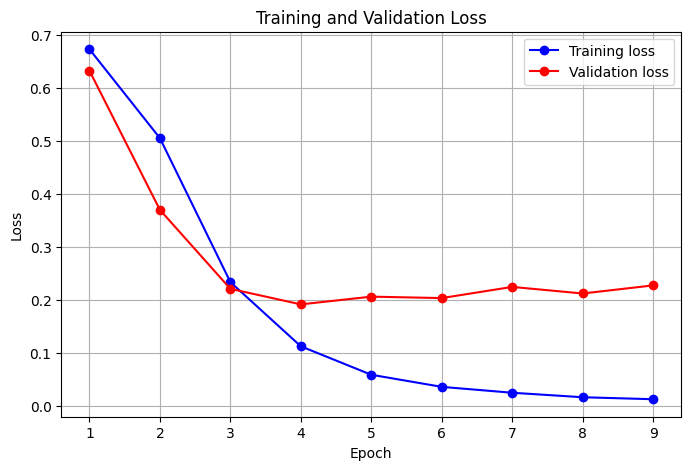

In [ ]:
# STEP 13: PLOT TRAINING CURVES

# Pull the recorded values out of the training history
acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

# ---- Plot 1: Accuracy ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, "b-o", label="Training accuracy")
plt.plot(epochs_range, val_acc, "r-o", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot 2: Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, "b-o", label="Training loss")
plt.plot(epochs_range, val_loss, "r-o", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test Accuracy : 0.9062
Precision     : 0.951
Recall        : 0.9065
F1-score      : 0.9282

Classification report:
              precision    recall  f1-score   support

     Genuine       0.83      0.91      0.86       159
        Fake       0.95      0.91      0.93       321

    accuracy                           0.91       480
   macro avg       0.89      0.91      0.90       480
weighted avg       0.91      0.91      0.91       480



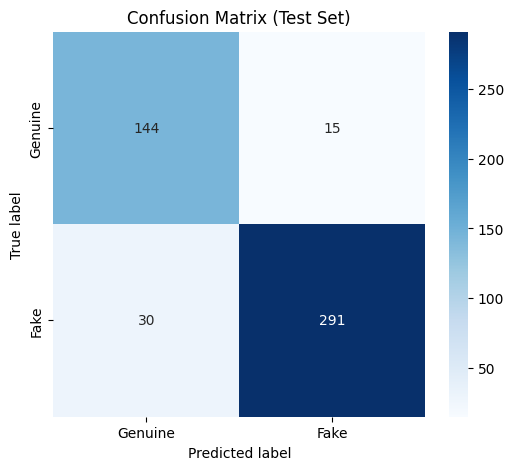

Genuine correctly identified (True Negatives) : 144
Genuine wrongly flagged as Fake (False Positives): 15
Fake wrongly passed as Genuine (False Negatives) : 30
Fake correctly caught (True Positives)        : 291


In [ ]:
# STEP 14: EVALUATE ON THE TEST SET

# The model outputs probabilities (0 to 1) for each test review
y_prob = model.predict(X_test_tfidf).ravel()

# Convert probabilities to classes: 0.5 or higher -> Fake (1), otherwise Genuine (0)
y_pred = (y_prob >= 0.5).astype(int)

# ---- Metrics ----
# For precision, recall and F1, "positive" means Fake (label 1)
print("Test Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision     :", round(precision_score(y_test, y_pred), 4))
print("Recall        :", round(recall_score(y_test, y_pred), 4))
print("F1-score      :", round(f1_score(y_test, y_pred), 4))

# ---- Detailed report for each class ----
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Genuine", "Fake"]))

# ---- Confusion matrix ----
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine", "Fake"],
            yticklabels=["Genuine", "Fake"])
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# ---- Explain the four boxes in plain words ----
tn, fp, fn, tp = cm.ravel()
print(f"Genuine correctly identified (True Negatives) : {tn}")
print(f"Genuine wrongly flagged as Fake (False Positives): {fp}")
print(f"Fake wrongly passed as Genuine (False Negatives) : {fn}")
print(f"Fake correctly caught (True Positives)        : {tp}")

In [ ]:

# STEP 15 : TEST ON NEW REVIEWS

def predict_review(text):
    """Take a raw review, clean it, and return the class and probability."""
    cleaned = clean_text(text)                                   # same cleaning as training
    features = tfidf.transform([cleaned]).toarray().astype("float32")  # text -> numbers
    prob_fake = float(model.predict(features, verbose=0)[0][0])  # probability of Fake

    if prob_fake >= 0.5:
        label = "Potentially Fake"
        confidence = prob_fake
    else:
        label = "Likely Genuine"
        confidence = 1 - prob_fake
    return label, prob_fake, confidence

# Some new reviews written by us (edit or add your own!)
new_reviews = [
    "We stayed here for three nights. The room was clean and the staff helped us find a good restaurant nearby. The bed was a bit hard but we slept fine.",
    "Exceptional accommodation. Superior service. Outstanding facilities. Highly recommended for all travelers seeking excellence.",
    "The breakfast was okay, nothing special. Our shower drained slowly and the elevator was slow, but the location near the station was great.",
    "This hotel offers a comprehensive range of amenities. The location is convenient. Rooms are functional. Staff are professional. Overall satisfactory.",
    "Loved it! Best hotel ever, everything was perfect, you must book now, five stars!!!"
]

print(f"{'Predicted class':<18} {'P(Fake)':<9} {'Confidence':<11} Review")
print("-" * 100)
for review in new_reviews:
    label, p_fake, conf = predict_review(review)
    print(f"{label:<18} {p_fake:<9.3f} {conf:<11.3f} {review[:60]}...")


Predicted class    P(Fake)   Confidence  Review
----------------------------------------------------------------------------------------------------
Likely Genuine     0.076     0.924       We stayed here for three nights. The room was clean and the ...
Potentially Fake   0.980     0.980       Exceptional accommodation. Superior service. Outstanding fac...
Likely Genuine     0.052     0.948       The breakfast was okay, nothing special. Our shower drained ...
Potentially Fake   0.972     0.972       This hotel offers a comprehensive range of amenities. The lo...
Potentially Fake   0.879     0.879       Loved it! Best hotel ever, everything was perfect, you must ...


In [ ]:

# STEP 16: SAVE MODEL AND VECTORIZER


import joblib
from google.colab import files

# Save the trained neural network in the Keras format
model.save("fake_review_model.keras")

# Save the TF-IDF vectorizer (with its learned vocabulary)
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

print("Saved: fake_review_model.keras")
print("Saved: tfidf_vectorizer.joblib")

# Download both files to your computer (needed for the Streamlit app)
files.download("fake_review_model.keras")
files.download("tfidf_vectorizer.joblib")

Saved: fake_review_model.keras
Saved: tfidf_vectorizer.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


loaded_model = keras.models.load_model("fake_review_model.keras")
loaded_tfidf = joblib.load("tfidf_vectorizer.joblib")

sample = clean_text(new_reviews[0])
prob = loaded_model.predict(loaded_tfidf.transform([sample]).toarray().astype("float32"), verbose=0)[0][0]
print("Reloaded model P(Fake) for sample review:", round(float(prob), 3))
print("Matches original?", np.isclose(prob, predict_review(new_reviews[0])[1]))

Reloaded model P(Fake) for sample review: 0.076
Matches original? True
